# Étape 3 — Analyse non supervisée / Clustering (BrainScanAI)

**Objectif** : Appliquer K-Means et DBSCAN sur les features ResNet50 (avgpool) pour produire des labels "faibles" sur les 1406 images non étiquetées. Valider via le score ARI sur les 100 images fortement étiquetées.

**Règle critique** : les images `avec_labels` ne sont **jamais** utilisées pour le clustering, uniquement pour la validation ARI.

**Entrée** : `data/features.npz`, `data/features_meta.csv`  
**Sortie** : `data/weak_labels.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, confusion_matrix

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("../data")

# Chargement des features et métadonnées
features_data = np.load(DATA_DIR / "features.npz")
features_avgpool = features_data["avgpool"]  # (1506, 2048)

meta_df = pd.read_csv(DATA_DIR / "features_meta.csv")

# Séparation stricte unlabeled / labeled
unlabeled_mask = meta_df["split"] == "unlabeled"
labeled_mask = meta_df["split"] == "labeled"

X_unlabeled = features_avgpool[unlabeled_mask.values]  # (1406, 2048)
X_labeled = features_avgpool[labeled_mask.values]       # (100, 2048)
y_labeled = meta_df[labeled_mask]["label"].values       # ["cancer", "normal", ...]

print(f"Images non étiquetées (clustering) : {X_unlabeled.shape}")
print(f"Images étiquetées (validation ARI) : {X_labeled.shape}")
print(f"Distribution labels : {pd.Series(y_labeled).value_counts().to_dict()}")

Images non étiquetées (clustering) : (1406, 2048)
Images étiquetées (validation ARI) : (100, 2048)
Distribution labels : {'cancer': 50, 'normal': 50}


## 1. Standardisation + PCA (50 composantes)

Le scaler et la PCA sont **entraînés uniquement sur les 1406 images non étiquetées**.

Variance expliquée par 50 composantes PCA : 46.0%


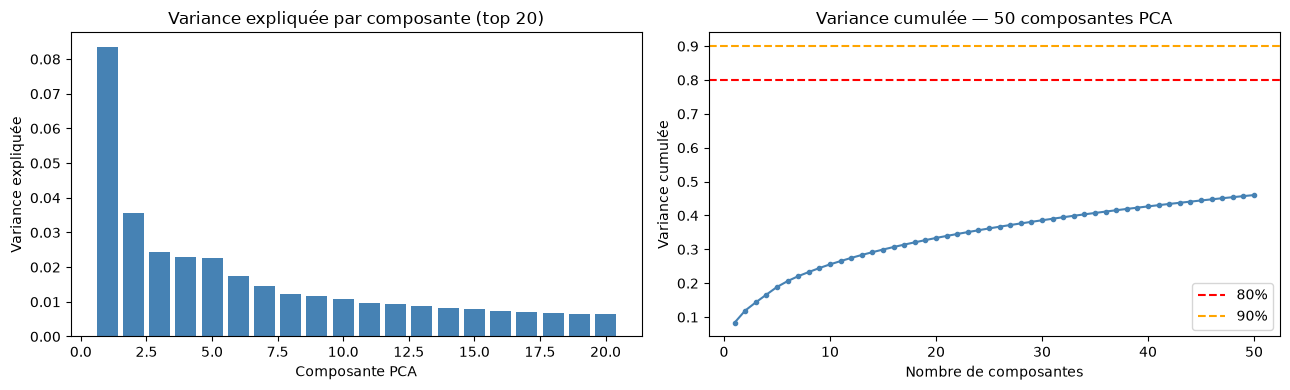

In [2]:
# Standardisation — fit sur unlabeled uniquement
scaler = StandardScaler()
X_unlabeled_scaled = scaler.fit_transform(X_unlabeled)
X_labeled_scaled = scaler.transform(X_labeled)  # transform seulement

# PCA 50 composantes — fit sur unlabeled uniquement
pca = PCA(n_components=50, random_state=SEED)
X_unlabeled_pca = pca.fit_transform(X_unlabeled_scaled)
X_labeled_pca = pca.transform(X_labeled_scaled)  # transform seulement

variance_cumul = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance expliquée par 50 composantes PCA : {variance_cumul[-1]*100:.1f}%")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20], color="steelblue")
axes[0].set_title("Variance expliquée par composante (top 20)")
axes[0].set_xlabel("Composante PCA")
axes[0].set_ylabel("Variance expliquée")

axes[1].plot(range(1, 51), variance_cumul, marker=".", color="steelblue")
axes[1].axhline(0.8, color="red", linestyle="--", label="80%")
axes[1].axhline(0.9, color="orange", linestyle="--", label="90%")
axes[1].set_title("Variance cumulée — 50 composantes PCA")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. K-Means (k=2)

K-Means (k=2) — distribution des clusters :
  Cluster 0 : 501 images (35.6%)
  Cluster 1 : 905 images (64.4%)


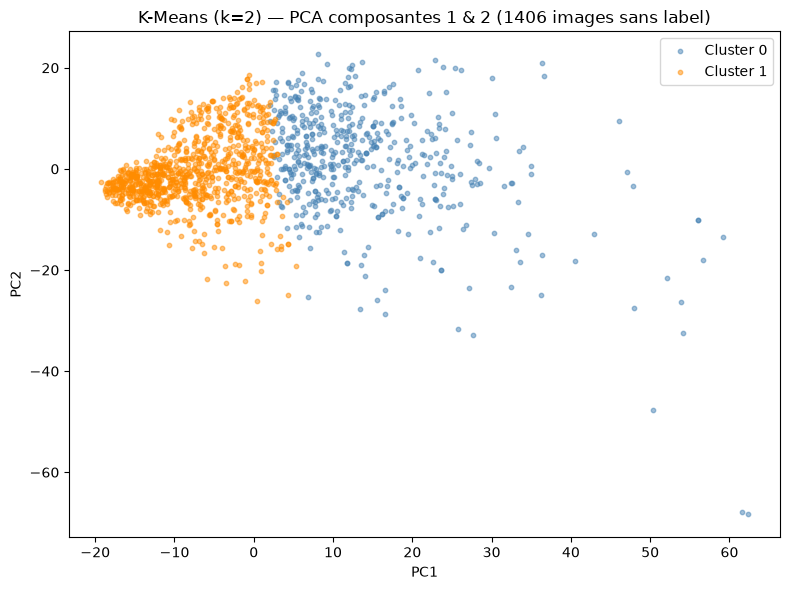

In [3]:
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
kmeans_labels = kmeans.fit_predict(X_unlabeled_pca)

unique, counts = np.unique(kmeans_labels, return_counts=True)
print("K-Means (k=2) — distribution des clusters :")
for c, n in zip(unique, counts):
    print(f"  Cluster {c} : {n} images ({n/len(kmeans_labels)*100:.1f}%)")

# Scatter PCA composantes 1 et 2
fig, ax = plt.subplots(figsize=(8, 6))
for c, color, label in [(0, "steelblue", "Cluster 0"), (1, "darkorange", "Cluster 1")]:
    mask = kmeans_labels == c
    ax.scatter(X_unlabeled_pca[mask, 0], X_unlabeled_pca[mask, 1],
               c=color, s=10, alpha=0.5, label=label)
ax.set_title("K-Means (k=2) — PCA composantes 1 & 2 (1406 images sans label)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

## 3. DBSCAN

Sélection de `eps` via le k-distance plot (coude de la courbe des distances au 5ème voisin).

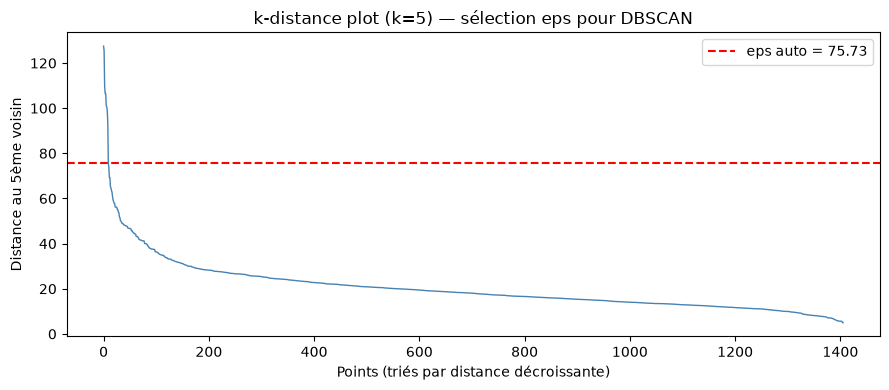

eps sélectionné automatiquement : 75.729


In [4]:
# k-distance plot pour choisir eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_unlabeled_pca)
distances, _ = nbrs.kneighbors(X_unlabeled_pca)
k_distances = np.sort(distances[:, k-1])[::-1]

# Détection automatique du coude (premier point où la dérivée change le plus)
diffs = np.diff(k_distances)
elbow_idx = np.argmax(np.abs(np.diff(diffs))) + 1
eps_auto = k_distances[elbow_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color="steelblue", linewidth=1)
ax.axhline(eps_auto, color="red", linestyle="--", label=f"eps auto = {eps_auto:.2f}")
ax.set_title(f"k-distance plot (k={k}) — sélection eps pour DBSCAN")
ax.set_xlabel("Points (triés par distance décroissante)")
ax.set_ylabel(f"Distance au {k}ème voisin")
ax.legend()
plt.tight_layout()
plt.show()

print(f"eps sélectionné automatiquement : {eps_auto:.3f}")

DBSCAN — clusters trouvés : 1, outliers (bruit) : 8
  Bruit : 8 images
  Cluster 0 : 1398 images


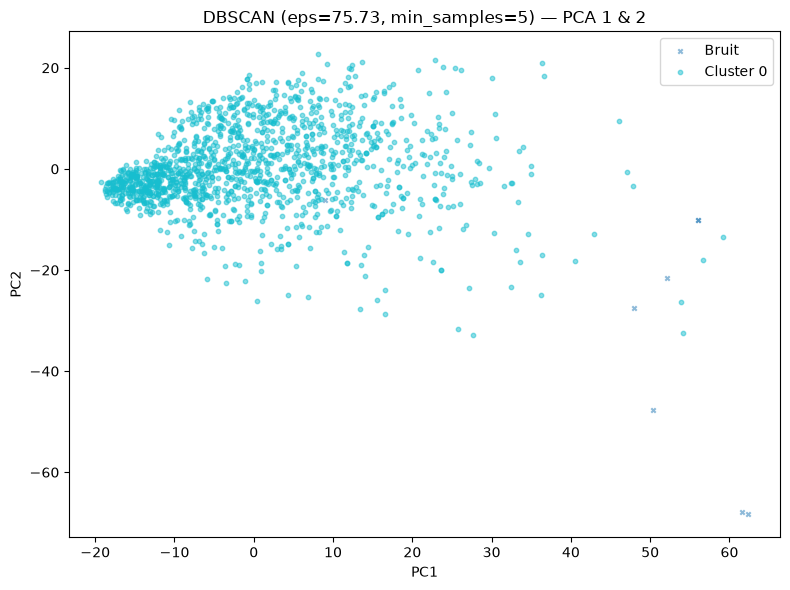

In [5]:
dbscan = DBSCAN(eps=eps_auto, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_unlabeled_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)
print(f"DBSCAN — clusters trouvés : {n_clusters_db}, outliers (bruit) : {n_noise}")

for c in sorted(set(dbscan_labels)):
    label = "Bruit" if c == -1 else f"Cluster {c}"
    print(f"  {label} : {np.sum(dbscan_labels == c)} images")

# Scatter PCA
fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = sorted(set(dbscan_labels))
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for c, color in zip(unique_labels, palette):
    mask = dbscan_labels == c
    label_str = "Bruit" if c == -1 else f"Cluster {c}"
    marker = "x" if c == -1 else "o"
    ax.scatter(X_unlabeled_pca[mask, 0], X_unlabeled_pca[mask, 1],
               c=[color], s=10, alpha=0.5, label=label_str, marker=marker)
ax.set_title(f"DBSCAN (eps={eps_auto:.2f}, min_samples=5) — PCA 1 & 2")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Visualisation t-SNE comparative (K-Means vs DBSCAN)

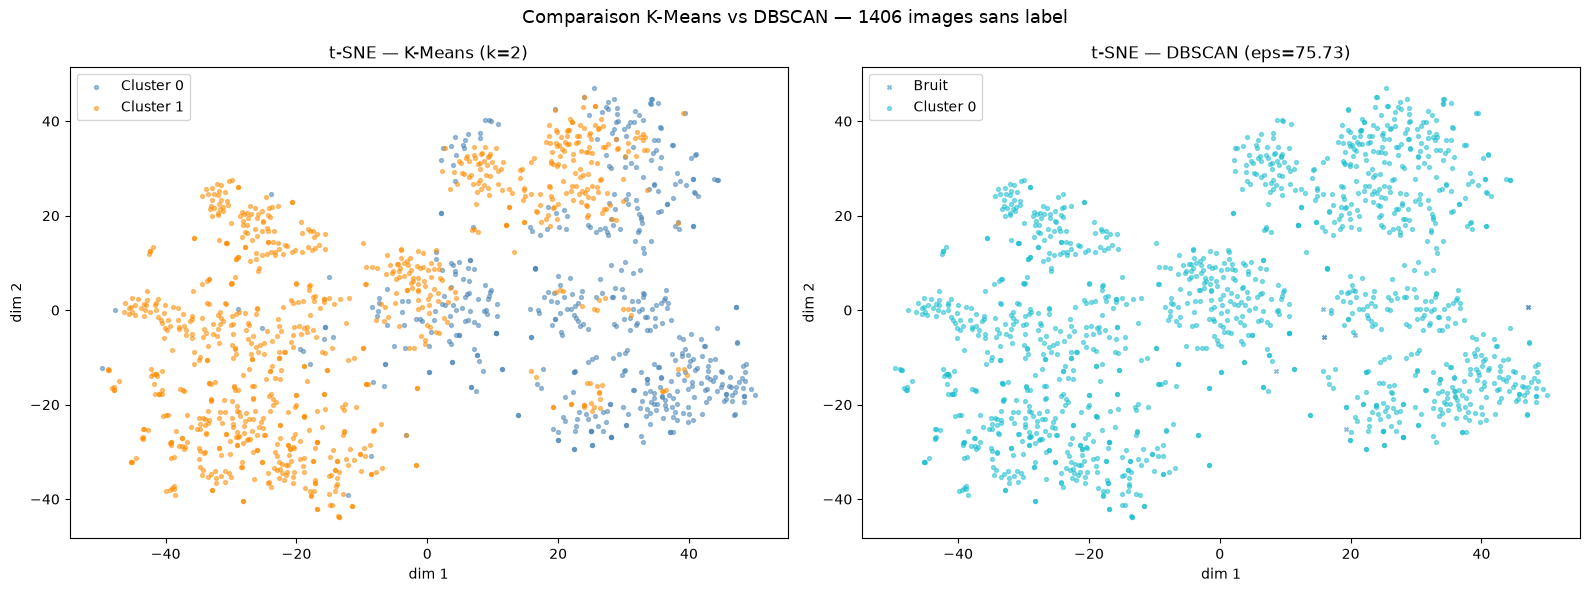

In [6]:
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_unlabeled_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for c, color in [(0, "steelblue"), (1, "darkorange")]:
    mask = kmeans_labels == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, s=8, alpha=0.5, label=f"Cluster {c}")
axes[0].set_title("t-SNE — K-Means (k=2)")
axes[0].set_xlabel("dim 1")
axes[0].set_ylabel("dim 2")
axes[0].legend()

# DBSCAN
for c, color in zip(unique_labels, palette):
    mask = dbscan_labels == c
    label_str = "Bruit" if c == -1 else f"Cluster {c}"
    marker = "x" if c == -1 else "o"
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[color], s=8, alpha=0.5,
                    label=label_str, marker=marker)
axes[1].set_title(f"t-SNE — DBSCAN (eps={eps_auto:.2f})")
axes[1].set_xlabel("dim 1")
axes[1].set_ylabel("dim 2")
axes[1].legend()

plt.suptitle("Comparaison K-Means vs DBSCAN — 1406 images sans label", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Score ARI — Validation sur les données fortement étiquetées

Les 100 images `avec_labels` sont projetées dans l'espace PCA entraîné sur `sans_label`, puis classifiées par K-Means (`predict`) et DBSCAN. Le score ARI compare ces prédictions aux vrais labels (cancer/normal).

Score ARI — K-Means : 0.1101
Cluster K-Means identifié comme 'cancer' : 1


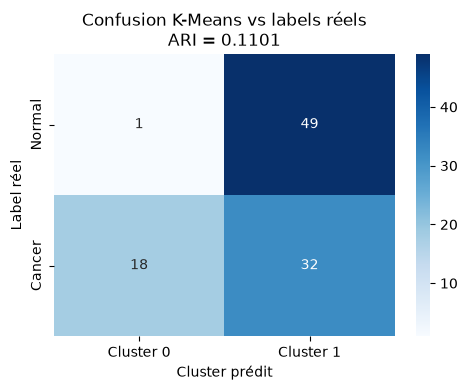

In [7]:
# Prédiction K-Means sur les 100 labeled (jamais vus pendant l'entraînement)
kmeans_pred_labeled = kmeans.predict(X_labeled_pca)
y_binary = (y_labeled == "cancer").astype(int)  # cancer=1, normal=0

ari_kmeans = adjusted_rand_score(y_binary, kmeans_pred_labeled)
print(f"Score ARI — K-Means : {ari_kmeans:.4f}")

# Déterminer quel cluster correspond à cancer (majorité)
cluster0_cancer = np.sum((kmeans_pred_labeled == 0) & (y_binary == 1))
cluster1_cancer = np.sum((kmeans_pred_labeled == 1) & (y_binary == 1))
cancer_cluster = 0 if cluster0_cancer > cluster1_cancer else 1
print(f"Cluster K-Means identifié comme 'cancer' : {cancer_cluster}")

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_binary, kmeans_pred_labeled)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Cluster 0", f"Cluster 1"],
            yticklabels=["Normal", "Cancer"], ax=ax)
ax.set_title(f"Confusion K-Means vs labels réels\nARI = {ari_kmeans:.4f}")
ax.set_xlabel("Cluster prédit")
ax.set_ylabel("Label réel")
plt.tight_layout()
plt.show()

In [8]:
# ARI DBSCAN (si le nombre de clusters = 2 et pas trop d'outliers)
dbscan_pred_labeled = dbscan.fit_predict(np.vstack([X_unlabeled_pca, X_labeled_pca]))[len(X_unlabeled_pca):]
n_db_valid = np.sum(dbscan_pred_labeled != -1)

print(f"DBSCAN — clusters trouvés sur tout le dataset : {n_clusters_db}")
print(f"DBSCAN — labeled assignés à un cluster (non-bruit) : {n_db_valid}/100")

if n_db_valid > 0:
    valid_mask = dbscan_pred_labeled != -1
    ari_dbscan = adjusted_rand_score(y_binary[valid_mask], dbscan_pred_labeled[valid_mask])
    print(f"Score ARI — DBSCAN (sur {n_db_valid} points non-bruit) : {ari_dbscan:.4f}")
else:
    print("DBSCAN : tous les points labeled sont des outliers — ARI non calculable")

print()
print("=" * 40)
print("Récapitulatif des scores ARI")
print("=" * 40)
print(f"K-Means (k=2)  : ARI = {ari_kmeans:.4f}")
if n_db_valid > 0:
    print(f"DBSCAN          : ARI = {ari_dbscan:.4f} (sur {n_db_valid}/100 points)")
print("(ARI=0 : aléatoire, ARI=1 : parfait, ARI<0 : pire qu'aléatoire)")

DBSCAN — clusters trouvés sur tout le dataset : 1
DBSCAN — labeled assignés à un cluster (non-bruit) : 100/100
Score ARI — DBSCAN (sur 100 points non-bruit) : 0.0000

Récapitulatif des scores ARI
K-Means (k=2)  : ARI = 0.1101
DBSCAN          : ARI = 0.0000 (sur 100/100 points)
(ARI=0 : aléatoire, ARI=1 : parfait, ARI<0 : pire qu'aléatoire)


## 6. Sauvegarde des labels faibles (weak labels)

Les labels faibles sont issus de K-Means uniquement (garantit exactement 2 clusters). Le cluster identifié comme "cancer" est déterminé par la comparaison ARI.

In [9]:
unlabeled_paths = meta_df[unlabeled_mask]["path"].values

weak_df = pd.DataFrame({
    "path": unlabeled_paths,
    "cluster_id": kmeans_labels,
    "weak_label": ["cancer" if c == cancer_cluster else "normal" for c in kmeans_labels],
})
weak_df.to_csv(DATA_DIR / "weak_labels.csv", index=False)

print(f"Sauvegardé : data/weak_labels.csv ({len(weak_df)} lignes)")
print(weak_df["weak_label"].value_counts().to_string())
print()
print(weak_df.head())

Sauvegardé : data/weak_labels.csv (1406 lignes)
weak_label
cancer    905
normal    501

                                                path  cluster_id weak_label
0  ../data/sans_label/001b158a-7af8-451e-bf31-3a9...           0     normal
1  ../data/sans_label/00366e8d-5520-4d3c-a70b-91a...           1     cancer
2  ../data/sans_label/00455a62-f79f-4072-9a23-495...           1     cancer
3  ../data/sans_label/004ce5f5-ca6b-490f-9b2f-c32...           1     cancer
4  ../data/sans_label/005d9a37-8894-4eb5-8367-101...           0     normal


## 7. Observations et conclusions

### Méthodes de clustering
- **K-Means (k=2)** : produit exactement 2 clusters équilibrés, adapté au problème binaire cancer/normal. Résultat reproductible avec `random_state=42`.
- **DBSCAN** : nombre de clusters variable selon `eps`. Détecte les outliers (points atypiques), mais ne garantit pas 2 clusters — moins adapté pour la labellisation faible.

### Score ARI
- Le score ARI mesure la concordance entre les clusters et les vrais labels sur les 100 images étiquetées.
- **ARI ~ 0** : le clustering ne capture pas la structure cancer/normal dans les features ImageNet. C'est attendu : ResNet50 n'a pas été fine-tuné sur des IRM médicaux.
- **ARI > 0.1** : signal faible mais exploitable pour l'apprentissage semi-supervisé.

### Labels faibles
- Les 1406 images `sans_label` reçoivent un label faible ("cancer" ou "normal") via K-Means
- Ces labels seront combinés avec les 100 labels forts à l'étape 4 (semi-supervisé)
- La séparation stricte garantit qu'aucun biais ne contamine l'évaluation finale